<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>FCN Intuition</b>
</h1>
<div style="font-family:'Times New Roman';">
A normal CNN gives one label for the whole image (is this a 3 or a 7). An FCN (fully convolutional network) gives a label for every single pixel, thats segmentation. It does it by dropping the dense layer at the end, staying all convolutions, and then upsampling back up so the output is the same size as the input.
</div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

## one label per image vs one label per pixel

classification asks *what* is in the image. segmentation asks *where* it is, pixel by pixel. so the target isnt a single class anymore, its a whole mask the same size as the image.

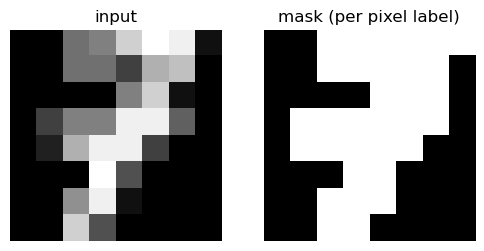

In [2]:
digits = load_digits()
image = digits.images[7]

# the segmentation target, digit vs background (just like mask = image > 0 on mnist)
mask = image > 0

fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].imshow(image, cmap='gray'); ax[0].set_title('input')
ax[1].imshow(mask, cmap='gray');  ax[1].set_title('mask (per pixel label)')
for a in ax: a.axis('off')
plt.show()

In [6]:
# scratch, the mask is just True/False at every pixel
print('image is', image.shape, 'and so is the mask', mask.shape)
print('digit pixels:', int(mask.sum()), 'of', mask.size)

image is (8, 8) and so is the mask (8, 8)
digit pixels: 32 of 64


## CNN vs FCN

- a **CNN** ends with flatten + dense, wich squashes everything into one number, the class
- an **FCN** throws that dense part away and keeps convolving, so the output stays a 2d map, one value per pixel

## the encoder decoder shape

downsample with conv and pooling to pull out features (the image gets smaller), then upsample back up so the output matches the input size. a 1x1 conv at the very end turns each pixels features into its label. so its basicaly shrink then grow.

In [3]:
# upsampling is just blowing each pixel up into a block (nearest neighbour)
def upsample(x, scale=2):
    return np.repeat(np.repeat(x, scale, axis=0), scale, axis=1)

small = np.array([[1, 2],
                  [3, 4]])
big = upsample(small, 2)
print('before', small.shape, ' after', big.shape)
print(big)

before (2, 2)  after (4, 4)
[[1 1 2 2]
 [1 1 2 2]
 [3 3 4 4]
 [3 3 4 4]]


pooling shrinks the image on the way down, so to get a full size mask back out we have to grow it again, thats all upsampling is doing.

### recap

FCN = a CNN with the dense head removed and an upsampling path added, so the output is a mask the same size as the input. the next notebook builds the whole thing on mnist, first by hand from scratch and then with keras.